In [ ]:
from datasets import load_dataset
import re, os, pickle
from tqdm import tqdm

### Load interventions

In [ ]:
dataset = load_dataset("CMU-AIRe/InT-SFT", split="train")

In [ ]:
results_dir = "OUTPUT_PATH"
all_results = {}

for start in tqdm(range(0, len(dataset), 1024)):
    end = min(start + 1024, len(dataset))
    pkl_name = f"interventions_{start}_{end}.pkl"
    pkl_path = os.path.join(results_dir, pkl_name)
    with open(pkl_path, "rb") as f:
        part = pickle.load(f)
        all_results.update(part)

print(f"Loaded {len(all_results)} results.")

### Parse guidance

In [4]:
def triple_quote_content(s):
    # Match "content": " ... "
    return re.sub(
        r'("content":\s*)"((?:[^"\\]|\\.)*)"',
        lambda m: f'{m.group(1)}"""{m.group(2)}"""',
        s
    )


def numberify_location(text: str) -> str:
    pattern = re.compile(
        r'(["\']location["\']\s*:\s*)'     # group 1: the key and colon
        r'(?:["\']?)[A-Za-z_]+\s*(\d+)(?:["\']?)'
    )
    return pattern.sub(lambda m: f'{m.group(1)}{m.group(2)}', text)


valid = set("n\\'\"")

def fix_invalid_escapes(s):
    return re.sub(
        r'\\(.)', 
        lambda m: '\\\\' + m.group(1) if m.group(1) not in valid else m.group(0),
        s
    )

In [ ]:
from datasets import Dataset
import textwrap, ast

pattern = r"<intervention>(.*?)</intervention>"

rows = []
for i in tqdm(range(len(dataset))):
    try:
        for j in range(len(all_results[i].outputs)):
            all_matches = re.findall(pattern, all_results[i].outputs[j].text, flags=re.DOTALL)
            match = all_matches[-1:]  # get the last match as a list (so len(match)==0 or 1)

            if len(match) > 1:
                print(f"{i}: Multiple matches")
                print(match)
            
            replacements = []
            for m in match:
                try:
                    replacements.append(ast.literal_eval(textwrap.dedent(fix_invalid_escapes(numberify_location(m)))))
                except Exception as e:
                    try:
                        replacements.append(ast.literal_eval(textwrap.dedent(fix_invalid_escapes(triple_quote_content(numberify_location(m))))))
                    except Exception as e:
                        # print(all_results[i].outputs[0].text)
                        # print(f"Error parsing guidance: {e}")
                        continue
                
            for replacement in replacements:
                row = dict(dataset[i])  # Make a new row for each student solution
                row['intervention'] = replacement
                
                try:
                    location = int(replacement['location'])
                except Exception as e:
                    location = int(re.search(r"(\d+)", str(replacement['location'])).group(1))
                row['intervention']['location'] = location

                if location == 1:
                    row['intervention_guided_attempt'] = replacement['content'].replace('\n', '\n\n')
                else:
                    prefix = "\n\n".join(row['incorrect_attempt'].split("\n\n")[:location - 1])
                    row['intervention_guided_attempt'] = prefix + "\n\n" + replacement['content'].replace('\n', '\n\n')
                
                row['self_verify_prompt'] = all_results[i].prompt
                row['self_verify_output'] = all_results[i].outputs[j].text
                
                rows.append(row)
    
    except Exception as e:
        # print(all_results[i].outputs[0].text)
        print(f"Error parsing guidance: {e}")

  8%|▊         | 1371/16190 [00:01<00:10, 1412.16it/s]

Error parsing guidance: 'NoneType' object has no attribute 'group'


 35%|███▌      | 5740/16190 [00:03<00:04, 2374.76it/s]

Error parsing guidance: 'NoneType' object has no attribute 'group'


100%|██████████| 16190/16190 [00:09<00:00, 1673.91it/s]


In [ ]:
guided_dataset = Dataset.from_list(rows)

In [ ]:
# remove oracle leakage
oracle_leaked = 0
for row in guided_dataset:
    if row['answer'] in row['intervention']['content']:
        oracle_leaked += 1

print(f"Oracle leaked in {oracle_leaked} out of {len(guided_dataset)} cases")
guided_dataset = guided_dataset.filter(lambda x: x['answer'] not in x['intervention']['content'])
print(len(guided_dataset))

(0.0, 250.0)

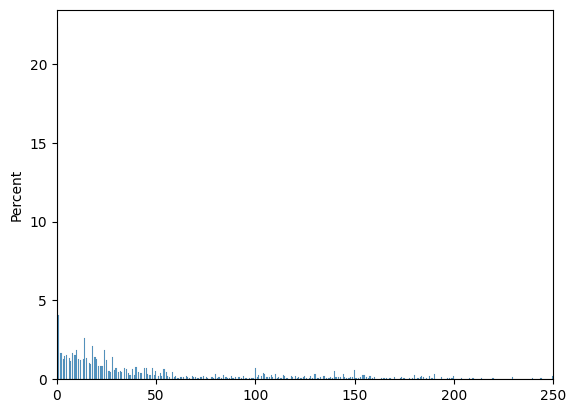

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
location_hist = [row['intervention']['location'] for row in guided_dataset]
sns.histplot(location_hist, stat="percent", bins=1000)
plt.xlim(0, 250)

In [ ]:
guided_dataset.push_to_hub("HF_NAME", split="train")